In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv('term-deposit-marketing-2020.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no


In [53]:
df.describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


In [54]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

In [56]:
df.shape

(40000, 14)

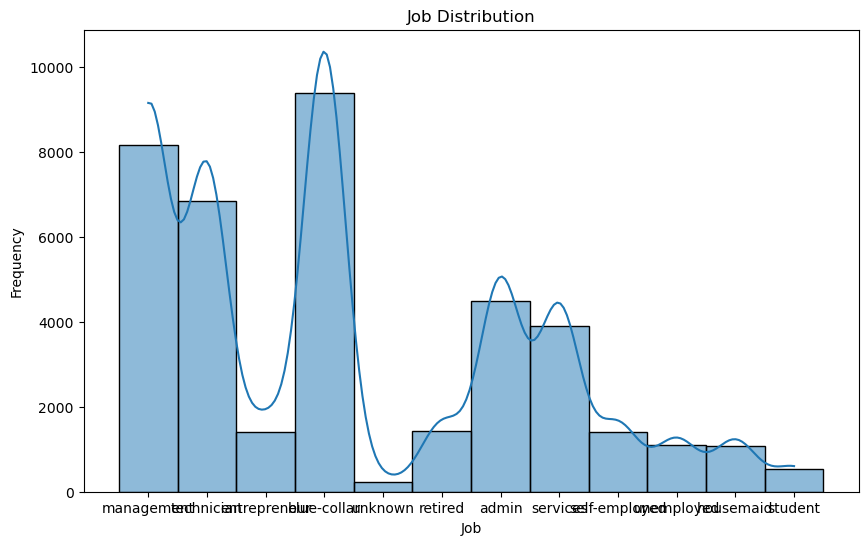

In [57]:
plt.figure(figsize= (10,6))
sns.histplot(df['job'], kde = True)
plt.title('Job Distribution')
plt.xlabel('Job')
plt.ylabel('Frequency')
plt.show()

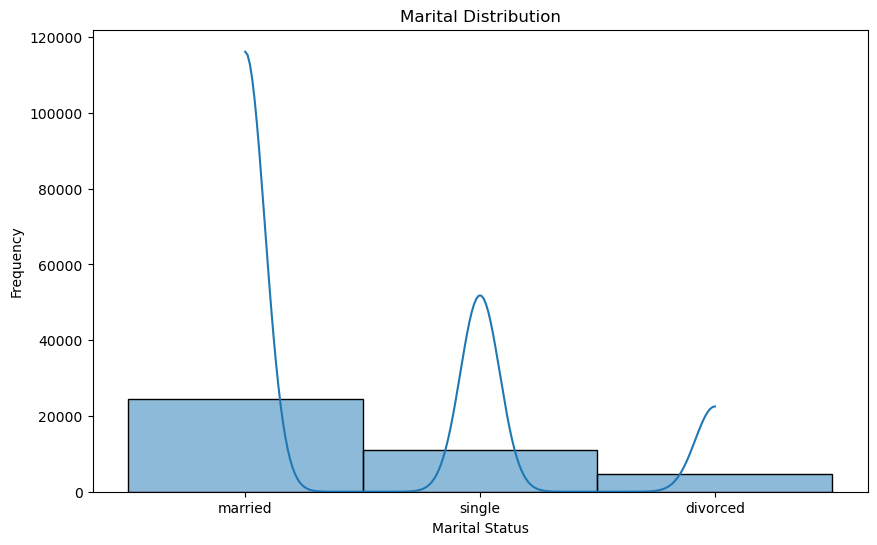

In [58]:
plt.figure(figsize= (10,6))
sns.histplot(df['marital'], kde = True)
plt.title('Marital Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Frequency')
plt.show()

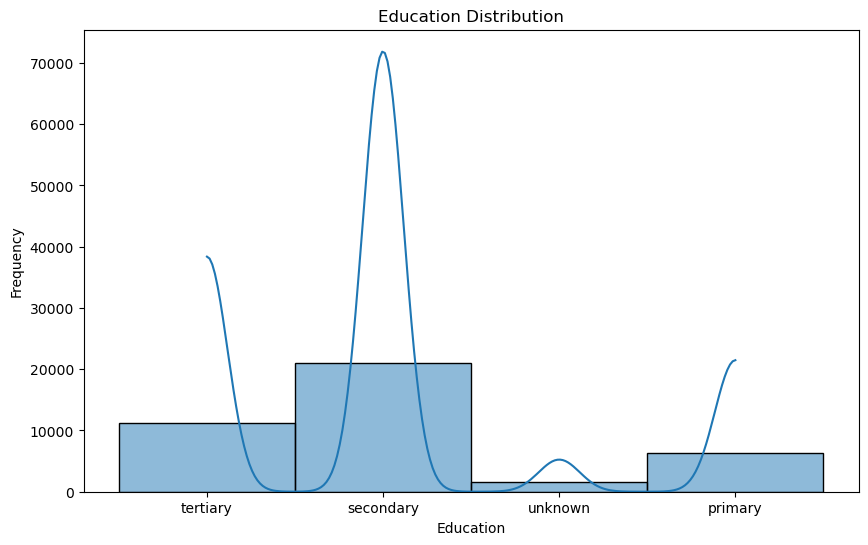

In [59]:
plt.figure(figsize= (10,6))
sns.histplot(df['education'], kde = True)
plt.title('Education Distribution')
plt.xlabel('Education')
plt.ylabel('Frequency')
plt.show()

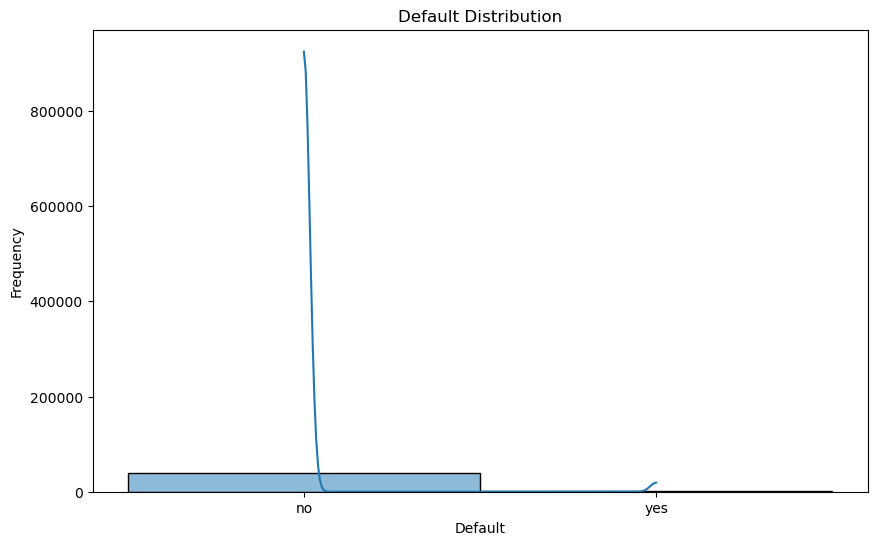

In [60]:
plt.figure(figsize= (10,6))
sns.histplot(df['default'], kde = True)
plt.title('Default Distribution')
plt.xlabel('Default')
plt.ylabel('Frequency')
plt.show()

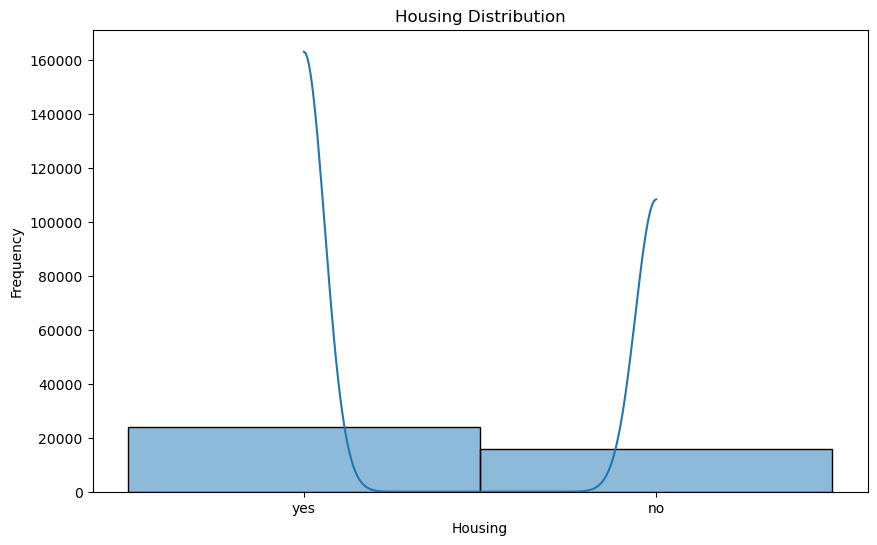

In [61]:
plt.figure(figsize= (10,6))
sns.histplot(df['housing'], kde = True)
plt.title('Housing Distribution')
plt.xlabel('Housing')
plt.ylabel('Frequency')
plt.show()

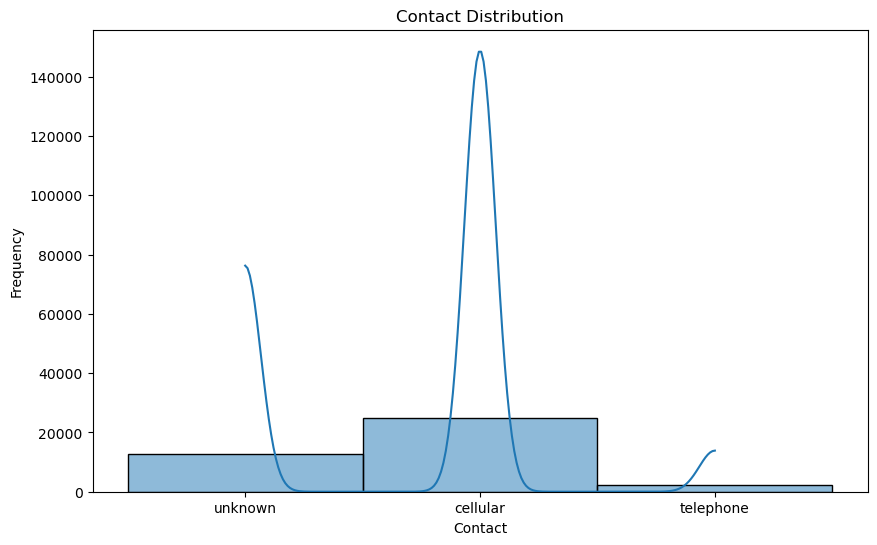

In [62]:
plt.figure(figsize= (10,6))
sns.histplot(df['contact'], kde = True)
plt.title('Contact Distribution')
plt.xlabel('Contact')
plt.ylabel('Frequency')
plt.show()

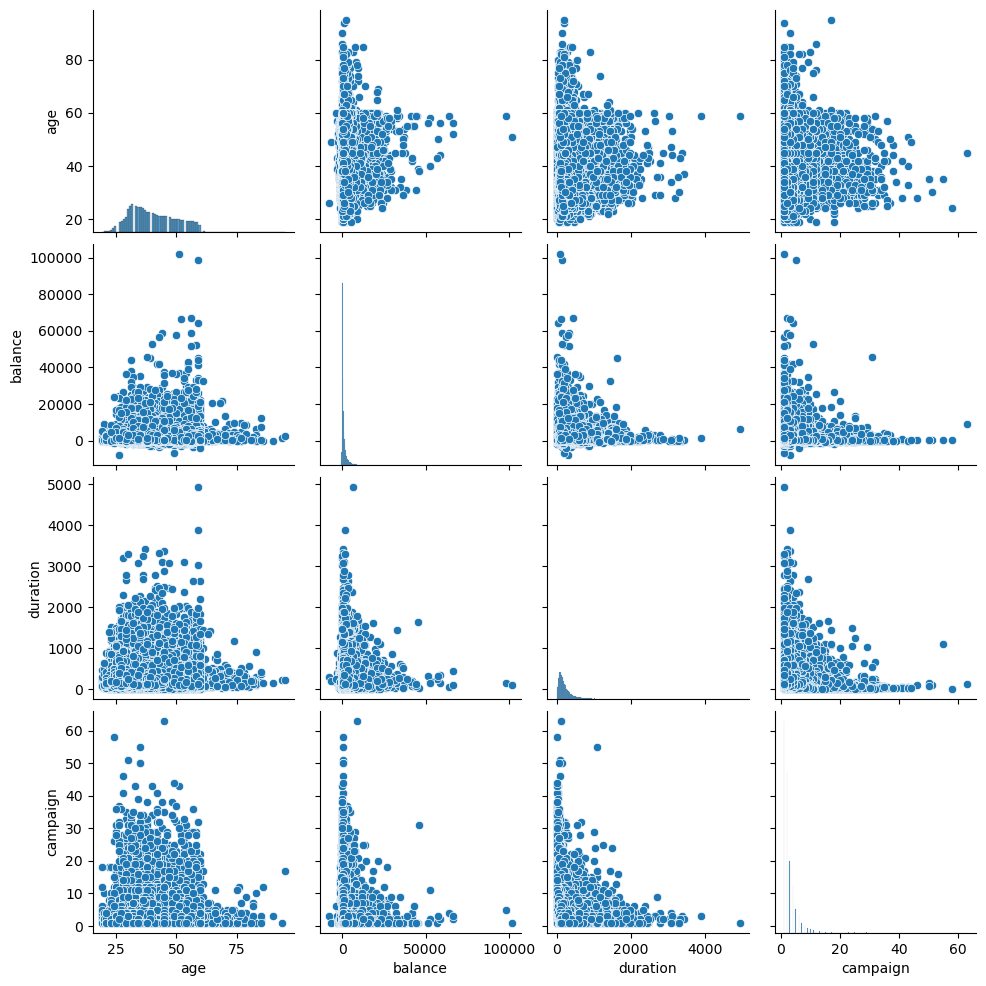

In [63]:
numeric_df = df[['age', 'balance', 'duration', 'campaign']]

sns.pairplot(numeric_df)
plt.show()

In [64]:
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import NearestCentroid
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
    Perceptron,
    RidgeClassifier,
    RidgeClassifierCV
)
from lazypredict.Supervised import LazyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import os

In [65]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])




In [66]:
print(df['y'].value_counts())

y
0    37104
1     2896
Name: count, dtype: int64


In [67]:
print(df['age'].value_counts())

age
32    1909
31    1826
33    1770
34    1730
35    1721
      ... 
90       1
94       1
86       1
95       1
81       1
Name: count, Length: 70, dtype: int64


In [69]:
df['age']

0        58
1        44
2        33
3        47
4        33
         ..
39995    53
39996    30
39997    54
39998    34
39999    38
Name: age, Length: 40000, dtype: int64

In [70]:
df = pd.get_dummies(
    df,
    columns=['job'],
    drop_first=False
)

df

,age,marital,education,default,balance,housing,loan,contact,day,month,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,58,married,tertiary,no,2143,yes,no,unknown,5,may,...,False,False,True,False,False,False,False,False,False,False
1,44,single,secondary,no,29,yes,no,unknown,5,may,...,False,False,False,False,False,False,False,True,False,False
2,33,married,secondary,no,2,yes,yes,unknown,5,may,...,True,False,False,False,False,False,False,False,False,False
3,47,married,unknown,no,1506,yes,no,unknown,5,may,...,False,False,False,False,False,False,False,False,False,False
4,33,single,unknown,no,1,no,no,unknown,5,may,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,married,tertiary,no,395,no,no,cellular,3,jun,...,False,False,False,False,False,False,False,True,False,False
39996,30,single,tertiary,no,3340,no,no,cellular,3,jun,...,False,False,True,False,False,False,False,False,False,False
39997,54,divorced,secondary,no,200,no,no,cellular,3,jun,...,False,False,False,False,False,False,False,False,False,False
39998,34,married,tertiary,no,1047,no,no,cellular,3,jun,...,False,False,True,False,False,False,False,False,False,False


In [71]:
df = pd.get_dummies(
    df,
    columns=['marital'],
    drop_first=False
)

In [72]:
df = pd.get_dummies(
    df,
    columns=['education'],
    drop_first=False
)

In [73]:
df = pd.get_dummies(
    df,
    columns=['housing'],
    drop_first=False
)

In [74]:
df = pd.get_dummies(
    df,
    columns=['contact'],
    drop_first=False
)
df

,age,default,balance,loan,day,month,duration,campaign,y,job_admin,...,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,housing_no,housing_yes,contact_cellular,contact_telephone,contact_unknown
0,58,no,2143,no,5,may,261,1,0,False,...,False,False,False,True,False,False,True,False,False,True
1,44,no,29,no,5,may,151,1,0,False,...,True,False,True,False,False,False,True,False,False,True
2,33,no,2,yes,5,may,76,1,0,False,...,False,False,True,False,False,False,True,False,False,True
3,47,no,1506,no,5,may,92,1,0,False,...,False,False,False,False,True,False,True,False,False,True
4,33,no,1,no,5,may,198,1,0,False,...,True,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,no,395,no,3,jun,107,1,0,False,...,False,False,False,True,False,True,False,True,False,False
39996,30,no,3340,no,3,jun,238,3,1,False,...,True,False,False,True,False,True,False,True,False,False
39997,54,no,200,no,3,jun,170,1,1,True,...,False,False,True,False,False,True,False,True,False,False
39998,34,no,1047,no,3,jun,342,1,0,False,...,False,False,False,True,False,True,False,True,False,False


In [75]:
df['day']=pd.cut(df.day, bins=[0,7,14,21,31], 
                                 labels=['first_week','second_week','third_week', 'fourth_week'], include_lowest=True)

In [76]:
def get_month_quarter(monthName):
    
    Name=""
        
    if monthName in [ 'mar', 'feb', 'jan']:
        Name ="Q1"
    elif monthName in ['apr', 'may','jun']:
        Name ="Q2"
    elif monthName in ['jul', 'aug', 'sep']:
        Name ="Q3"
    else:
        Name ="Q4"
    
    return Name

# Add new_month column in Training Features - containing categories for month
df['month'] = [  get_month_quarter(month) for month in df.month ]

In [78]:
df = pd.get_dummies(
    df,
    columns=['month'],
    drop_first=False
)

df

,age,default,balance,loan,day,duration,campaign,y,job_admin,job_blue-collar,...,education_unknown,housing_no,housing_yes,contact_cellular,contact_telephone,contact_unknown,month_Q1,month_Q2,month_Q3,month_Q4
0,58,no,2143,no,first_week,261,1,0,False,False,...,False,False,True,False,False,True,False,True,False,False
1,44,no,29,no,first_week,151,1,0,False,False,...,False,False,True,False,False,True,False,True,False,False
2,33,no,2,yes,first_week,76,1,0,False,False,...,False,False,True,False,False,True,False,True,False,False
3,47,no,1506,no,first_week,92,1,0,False,True,...,True,False,True,False,False,True,False,True,False,False
4,33,no,1,no,first_week,198,1,0,False,False,...,True,True,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,no,395,no,first_week,107,1,0,False,False,...,False,True,False,True,False,False,False,True,False,False
39996,30,no,3340,no,first_week,238,3,1,False,False,...,False,True,False,True,False,False,False,True,False,False
39997,54,no,200,no,first_week,170,1,1,True,False,...,False,True,False,True,False,False,False,True,False,False
39998,34,no,1047,no,first_week,342,1,0,False,False,...,False,True,False,True,False,False,False,True,False,False


In [79]:
df = pd.get_dummies(
    df,
    columns=['default'],
    drop_first=False
)
df

,age,balance,loan,day,duration,campaign,y,job_admin,job_blue-collar,job_entrepreneur,...,housing_yes,contact_cellular,contact_telephone,contact_unknown,month_Q1,month_Q2,month_Q3,month_Q4,default_no,default_yes
0,58,2143,no,first_week,261,1,0,False,False,False,...,True,False,False,True,False,True,False,False,True,False
1,44,29,no,first_week,151,1,0,False,False,False,...,True,False,False,True,False,True,False,False,True,False
2,33,2,yes,first_week,76,1,0,False,False,True,...,True,False,False,True,False,True,False,False,True,False
3,47,1506,no,first_week,92,1,0,False,True,False,...,True,False,False,True,False,True,False,False,True,False
4,33,1,no,first_week,198,1,0,False,False,False,...,False,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,395,no,first_week,107,1,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False
39996,30,3340,no,first_week,238,3,1,False,False,False,...,False,True,False,False,False,True,False,False,True,False
39997,54,200,no,first_week,170,1,1,True,False,False,...,False,True,False,False,False,True,False,False,True,False
39998,34,1047,no,first_week,342,1,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [80]:
df = pd.get_dummies(
    df,
    columns=['loan'],
    drop_first=False
)


In [81]:
df = pd.get_dummies(
    df,
    columns=['day'],
    drop_first=False
)

df

,age,balance,duration,campaign,y,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_Q3,month_Q4,default_no,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week
0,58,2143,261,1,0,False,False,False,False,True,...,False,False,True,False,True,False,True,False,False,False
1,44,29,151,1,0,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
2,33,2,76,1,0,False,False,True,False,False,...,False,False,True,False,False,True,True,False,False,False
3,47,1506,92,1,0,False,True,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,33,1,198,1,0,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,395,107,1,0,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
39996,30,3340,238,3,1,False,False,False,False,True,...,False,False,True,False,True,False,True,False,False,False
39997,54,200,170,1,1,True,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
39998,34,1047,342,1,0,False,False,False,False,True,...,False,False,True,False,True,False,True,False,False,False


In [82]:
X = df.drop('y', axis=1)
y = df['y']

In [83]:
X.columns

Index(['age', 'balance', 'duration', 'campaign', 'job_admin',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'housing_no', 'housing_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'month_Q1', 'month_Q2',
       'month_Q3', 'month_Q4', 'default_no', 'default_yes', 'loan_no',
       'loan_yes', 'day_first_week', 'day_second_week', 'day_third_week',
       'day_fourth_week'],
      dtype='object')

In [84]:
cols_to_scale = ['age', 'balance', 'duration', 'campaign']

scaler = StandardScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

X

,age,balance,duration,campaign,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_Q3,month_Q4,default_no,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week
0,1.810415,0.299174,0.023811,-0.581096,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False
1,0.358382,-0.428854,-0.400305,-0.581096,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
2,-0.782501,-0.438152,-0.689474,-0.581096,False,False,True,False,False,False,...,False,False,True,False,False,True,True,False,False,False
3,0.669532,0.079802,-0.627785,-0.581096,False,True,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,-0.782501,-0.438497,-0.219092,-0.581096,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,1.291832,-0.302809,-0.569951,-0.581096,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
39996,-1.093650,0.711402,-0.064868,0.036377,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False
39997,1.395549,-0.369964,-0.327048,-0.581096,True,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
39998,-0.678784,-0.078271,0.336114,-0.581096,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False


In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234, stratify=y)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])


models = {
    'LogisticRegression': LogisticRegression(class_weight = 'balanced'),
    'RandomForestClassifier': RandomForestClassifier(
        class_weight = 'balanced',random_state=1234
    ),
    'GradientBoosting': GradientBoostingClassifier(
        random_state=42
    ),
    'XGBoostClassifier': XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=1234
    ),
    'LGBMClassifier': LGBMClassifier(
        class_weight = 'balanced',
        random_state=1234,
        verbose=-1
    ),
    'SGDClassifier': SGDClassifier(
        class_weight = 'balanced',
        random_state=1234
    ),
    'BernoulliNB': BernoulliNB(),
    'GaussianNB': GaussianNB(),
    'NearestCentroid': NearestCentroid(),
    'Perceptron': Perceptron(
        class_weight = 'balanced',
        random_state=1234
    ),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
    'RidgeClassifier': RidgeClassifier(class_weight = 'balanced'),
    'RidgeClassifierCV': RidgeClassifierCV(class_weight = 'balanced')
}

model_grids = {

    'LogisticRegression': {
        'class_weight' : ['balanced'],
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },

    'RandomForestClassifier': {
        'class_weight' : ['balanced'],
        'n_estimators': [100, 200, 300],
        'max_depth': [1, 5]
    },

    'GradientBoosting': {
        
        'n_estimators': [100, 200, 300, 400, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 4, 5, 6, 7, 8]
    },

    'XGBoostClassifier': {
        'class_weight' : ['balanced'],
        'n_estimators': [100, 200, 300],
        'max_depth': [2, 3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9]
    },

    'LGBMClassifier': {
        'class_weight' : ['balanced'],
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'objective': ['binary'],
        'is_unbalance': [True],
        'metric': ['auc'],
        'min_split_gain': [0.01],
        'boosting_type': ['gbdt', 'dart'],
        'colsample_bytree': [0.5, 0.7,0.8,0.9,1.0],
        'num_leaves': [20, 30, 40, 50, 60, 70, 80],
        'random_state': [1234]
    },

    'SGDClassifier': {
        'class_weight' : ['balanced'],
        'loss': ['log_loss', 'hinge'],
        'alpha': [0.0001, 0.001, 0.01]
    },

    'BernoulliNB': {
        'alpha': [0.1, 0.5, 1.0]
    },

    'GaussianNB': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },

    'NearestCentroid': {
        'metric': ['euclidean', 'manhattan']
    },

    'Perceptron': {
        'class_weight' : ['balanced'],
        'penalty': [None, 'l2'],
        'alpha': [0.0001, 0.001]
    },

    'LinearDiscriminantAnalysis': {
        'solver' : ['svd', 'lsqr', 'eigen']
    },

    'RidgeClassifier': {
        'class_weight' : ['balanced'],
        'alpha': [0.1, 1.0, 10.0]
    },

    'RidgeClassifierCV': {
        'class_weight' : ['balanced'],
        'alphas': [[0.1, 1.0, 10.0]]
    }
}

#Fit the scaler on train feature set


clf = LazyClassifier(verbose=1,ignore_warnings=True, custom_metric=None, random_state = 1234)
models_output,predictions = clf.fit(X_train, X_test, y_train, y_test)

models_output

import mlflow

mlflow_tracking_uri = 'http://localhost:5555'  
if mlflow_tracking_uri:
    mlflow.set_tracking_uri(mlflow_tracking_uri)
    mlflow.set_experiment("Term_Deposit_Marketing")

def evaluate_model_with_gridsearch(name, model, grid, X_train, y_train, X_test, y_test):
    if grid:
        clf = GridSearchCV(model, grid, cv=5, scoring='roc_auc', n_jobs=-1)
        #clf = RandomizedSearchCV(model, grid, verbose=1, 
        #                      cv=5, n_jobs = -1, n_iter=8, scoring='roc_auc')
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = model.get_params()

    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if hasattr(best_model, "predict_proba"):
        y_scores = best_model.predict_proba(X_test)[:, 1]
    
    elif hasattr(best_model, "decision_function"):
        y_scores = best_model.decision_function(X_test)
    else:
        y_scores = best_model.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_scores)

    
    return {
        'accuracy': accuracy,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'model': best_model,
        'params': best_params
    }

print("MLflow tracking URI:", mlflow_tracking_uri)

results = {}
with mlflow.start_run(run_name="Term_Deposit_Marketing") if mlflow_tracking_uri else nullcontext():
    for name, model in models.items():
        with mlflow.start_run(run_name=name, nested=True) if mlflow_tracking_uri else nullcontext():
            
        
            print("Current name:", name)
            print("model", model)
            evaluation = evaluate_model_with_gridsearch(name, model, model_grids[name], X_train, y_train, X_test, y_test)
            print("Returned keys:", evaluation)
            results[name] = evaluation

            if mlflow_tracking_uri:
                mlflow.log_params(evaluation['params'])
                mlflow.log_metrics({
                    'accuracy': evaluation['accuracy'],  
                    'mae': evaluation['mae'],
                    'mse': evaluation['mse'],
                    'rmse': evaluation['rmse'],
                    'r2': evaluation['r2'],
                    'f1_score': evaluation['f1_score'],
                    'roc_auc': evaluation['roc_auc']
                })
                
            
            print(
            f"{name} Accuracy: {evaluation['accuracy']:.4f}, "
            f"R2: {evaluation['r2']:.4f}, "
            f"RMSE: {evaluation['rmse']:.2f}, "
            f"f1_score: {evaluation['f1_score']:.4f}, "
            f"ROC_AUC: {evaluation['roc_auc']:.4f}"
            )

import yaml
import os
# Save model config with selected features 
# Display information about the best model
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
best_params = best_model.get_params()
best_accuracy = float(results[best_model_name]['accuracy'])
best_mae = float(results[best_model_name]['mae'])
best_rmse = float(results[best_model_name]['rmse'])
best_f1_score = float(results[best_model_name]['f1_score'])
best_roc_auc_score = float(results[best_model_name]['roc_auc'])

print(f"🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   f1 Score: {best_f1_score:.4f}")
print(f"   ROC_AUC: {best_roc_auc_score:.4f}")
print(f"   MAE: {best_mae:.4f}")
print(f"   RMSE: {best_rmse:.4f}")

model_config = {
    'model': {
        'name': 'Term_deposit_marketing_model',
        'best_model': best_model_name,
        'parameters': best_params,
        'accuracy': best_accuracy,
        'mae': best_mae,
        'best_f1_score': best_f1_score,
        'best_roc_auc_score': best_roc_auc_score,
        'target_variable': 'Y',
        
    }
}

print(model_config)

2026/06/27 21:29:43 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/06/27 21:29:44 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/27 21:29:44 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/06/27 21:29:44 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


  0%|          | 0/32 [00:00<?, ?it/s]

2026/06/27 21:29:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 21:29:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 21:29:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'lazy_classifier_AdaBoostClassifier' already exists. Creating a new versio

🏃 View run LazyClassifier-AdaBoostClassifier at: http://localhost:5555/#/experiments/1/runs/677b693fb375442e86626fe4136b4698
🧪 View experiment at: http://localhost:5555/#/experiments/1


2026/06/27 21:29:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 21:29:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 21:29:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'lazy_classifier_BaggingClassifier' already exists. Creating a new version

...

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7421
           1       0.52      0.41      0.46       579

    accuracy                           0.93      8000
   macro avg       0.74      0.69      0.71      8000
weighted avg       0.92      0.93      0.93      8000

[[7202  219]
 [ 341  238]]
Returned keys: {'accuracy': 0.93, 'mae': 0.07, 'mse': 0.07, 'rmse': np.float64(0.2645751311064591), 'r2': -0.04264632947763647, 'f1_score': 0.4594594594594595, 'roc_auc': 0.9115882459314103, 'model': LinearDiscriminantAnalysis(solver='lsqr'), 'params': {'solver': 'lsqr'}}
LinearDiscriminantAnalysis Accuracy: 0.9300, R2: -0.0426, RMSE: 0.26, f1_score: 0.4595, ROC_AUC: 0.9116
🏃 View run LinearDiscriminantAnalysis at: http://localhost:5555/#/experiments/1/runs/ec9a8547266b48b5860139d635e0d1bb
🧪 View experiment at: http://localhost:5555/#/experiments/1
Current name: RidgeClassifier
model RidgeClassifier(class_weight='balanced')


2026/06/27 23:30:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 23:30:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 23:30:58 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.


              precision    recall  f1-score   support

           0       0.98      0.88      0.93      7421
           1       0.33      0.79      0.46       579

    accuracy                           0.87      8000
   macro avg       0.66      0.83      0.69      8000
weighted avg       0.93      0.87      0.89      8000

[[6494  927]
 [ 124  455]]
Returned keys: {'accuracy': 0.868625, 'mae': 0.131375, 'mse': 0.131375, 'rmse': np.float64(0.36245689398878866), 'r2': -0.9568237362160643, 'f1_score': 0.46404895461499235, 'roc_auc': 0.9097396432985886, 'model': RidgeClassifier(alpha=10.0, class_weight='balanced'), 'params': {'alpha': 10.0, 'class_weight': 'balanced'}}
RidgeClassifier Accuracy: 0.8686, R2: -0.9568, RMSE: 0.36, f1_score: 0.4640, ROC_AUC: 0.9097
🏃 View run RidgeClassifier at: http://localhost:5555/#/experiments/1/runs/1bad0206be4643279e5f0066787b3a2f
🧪 View experiment at: http://localhost:5555/#/experiments/1
Current name: RidgeClassifierCV
model RidgeClassifierCV(class_we

2026/06/27 23:30:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 23:31:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 23:31:02 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.


              precision    recall  f1-score   support

           0       0.98      0.88      0.93      7421
           1       0.33      0.79      0.46       579

    accuracy                           0.87      8000
   macro avg       0.66      0.83      0.69      8000
weighted avg       0.93      0.87      0.89      8000

[[6494  927]
 [ 124  455]]
Returned keys: {'accuracy': 0.868625, 'mae': 0.131375, 'mse': 0.131375, 'rmse': np.float64(0.36245689398878866), 'r2': -0.9568237362160643, 'f1_score': 0.46404895461499235, 'roc_auc': 0.9097396432985886, 'model': RidgeClassifierCV(alphas=[0.1, 1.0, 10.0], class_weight='balanced'), 'params': {'alphas': [0.1, 1.0, 10.0], 'class_weight': 'balanced'}}
RidgeClassifierCV Accuracy: 0.8686, R2: -0.9568, RMSE: 0.36, f1_score: 0.4640, ROC_AUC: 0.9097
🏃 View run RidgeClassifierCV at: http://localhost:5555/#/experiments/1/runs/704036bf40414620a6aae62b2c0c7780
🧪 View experiment at: http://localhost:5555/#/experiments/1
🏃 View run Term_Deposit_Marketin

In [36]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(50))

                Feature  Importance
2              duration    0.122638
27      contact_unknown    0.088041
23           housing_no    0.084329
30             month_Q3    0.074804
24          housing_yes    0.070673
29             month_Q2    0.055257
31             month_Q4    0.052309
28             month_Q1    0.047701
39      day_fourth_week    0.038242
38       day_third_week    0.027421
35             loan_yes    0.024178
25     contact_cellular    0.022157
21   education_tertiary    0.020866
37      day_second_week    0.018213
34              loan_no    0.017407
26    contact_telephone    0.016847
5       job_blue-collar    0.014935
17      marital_married    0.014472
36       day_first_week    0.013204
19    education_primary    0.012779
11         job_services    0.011215
0                   age    0.011210
1               balance    0.010713
3              campaign    0.010673
20  education_secondary    0.010606
13       job_technician    0.010060
18       marital_single    0

In [247]:
df_subscribed = df[df['y']==1]
df_subscribed = df_subscribed.drop('y', axis = 1)
df_subscribed

,age,balance,duration,campaign,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_Q3,month_Q4,default_no,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week
83,59,2343,1042,1,True,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
86,56,45,1467,1,True,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
87,41,1270,1389,1,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
129,55,2476,579,1,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
168,54,184,673,2,True,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,29,637,340,1,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False
39988,55,2383,591,2,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False
39990,26,1231,385,2,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
39996,30,3340,238,3,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False


In [248]:
scaler_3 = StandardScaler()
df_numeric_2 = df_subscribed.copy()
df_numeric_2[['age', 'balance', 'duration', 'campaign']]= scaler_3.fit_transform(df_numeric_2[['age', 'balance', 'duration', 'campaign']])
df_numeric_2

,age,balance,duration,campaign,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_Q3,month_Q4,default_no,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week
83,1.741354,0.258004,0.832632,-0.613443,True,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
86,1.468629,-0.527801,1.818224,-0.613443,True,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
87,0.105003,-0.108910,1.637339,-0.613443,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
129,1.377720,0.303484,-0.241084,-0.613443,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
168,1.286812,-0.480270,-0.023094,-0.179720,True,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False
39988,1.377720,0.271682,-0.213256,-0.179720,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False
39990,-1.258623,-0.122246,-0.690978,-0.179720,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
39996,-0.894989,0.598930,-1.031877,0.254004,False,False,False,False,True,False,...,False,False,True,False,True,False,True,False,False,False


2026/07/10 16:44:19 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '81fe3300791d413d8ab367e57249e337', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/10 16:44:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 16:44:22 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/07/10 16:44:22 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f5800d3

🏃 View run brawny-donkey-196 at: http://localhost:5555/#/experiments/1/runs/81fe3300791d413d8ab367e57249e337
🧪 View experiment at: http://localhost:5555/#/experiments/1


2026/07/10 16:44:24 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/07/10 16:44:24 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'b10b844932f04cecbf1835f55e62f1b9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/10 16:44:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run bedecked-grub-545 at: http://localhost:5555/#/experiments/1/runs/f5800d30bb9c4839ac41d7d20463a6f1
🧪 View experiment at: http://localhost:5555/#/experiments/1


2026/07/10 16:44:26 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/07/10 16:44:26 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2ccffce62b3e465cadc84d0b237ac7f8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/10 16:44:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run rebellious-colt-284 at: http://localhost:5555/#/experiments/1/runs/0637419fdc274c84a42a6335f04024b4
🧪 View experiment at: http://localhost:5555/#/experiments/1


2026/07/10 16:44:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 16:44:46 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/07/10 16:44:46 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '23540888fcf446bb904a0dcac2c08b5d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run delightful-tern-89 at: http://localhost:5555/#/experiments/1/runs/b4f65d6028db46a4a521793c46d68a40
🧪 View experiment at: http://localhost:5555/#/experiments/1


2026/07/10 16:44:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 16:44:48 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


🏃 View run grandiose-hen-332 at: http://localhost:5555/#/experiments/1/runs/23540888fcf446bb904a0dcac2c08b5d
🧪 View experiment at: http://localhost:5555/#/experiments/1


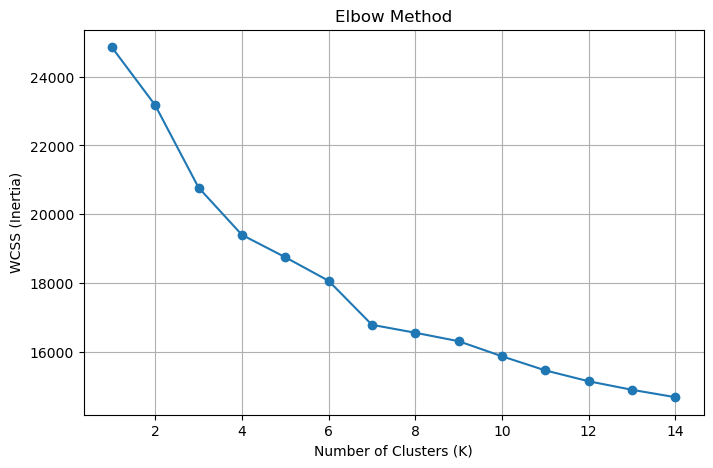

In [249]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 15):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )
    kmeans.fit(df_numeric_2)
    wcss.append(kmeans.inertia_)  # WCSS

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 15), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method')
plt.grid(True)
plt.show()


In [251]:

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

labels = KMeans3.labels_

print("Number of clusters:", len(set(labels)))
print("----------------------------")
print("Inertia:", KMeans3.inertia_)
print("Silhouette Score:", silhouette_score(df_numeric_2, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(df_numeric_2, labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(df_numeric_2, labels))

Number of clusters: 3
----------------------------
Inertia: 20774.981927040575
Silhouette Score: 0.10634214400236383
Davies-Bouldin Index: 2.513684436798727
Calinski-Harabasz Index: 283.9540301862253


In [169]:
cluster_counts = pd.Series(KMeans3.labels_).value_counts().sort_index()
print(cluster_counts)

0    1416
1     805
2     675
Name: count, dtype: int64


2026/07/11 21:18:46 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3bff45b3015f4e14abc380992010e5a2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/11 21:18:55 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/07/11 21:18:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/11 21:18:55 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/11 21:18:57 WARNI

🏃 View run adaptable-flea-870 at: http://localhost:5555/#/experiments/1/runs/3bff45b3015f4e14abc380992010e5a2
🧪 View experiment at: http://localhost:5555/#/experiments/1


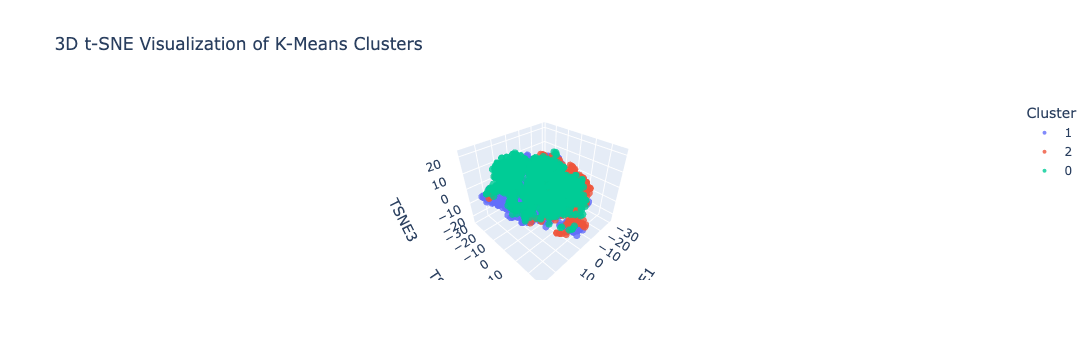

In [253]:
from sklearn.manifold import TSNE
import plotly.express as px

# Run t-SNE with 3 components
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(df_numeric_2)

# Create DataFrame for Plotly
tsne_df = pd.DataFrame(
    {
        "TSNE1": X_tsne[:,0],
        "TSNE2": X_tsne[:,1],
        "TSNE3": X_tsne[:,2],
        "Cluster": KMeans3.labels_.astype(str)
    }
)

# Interactive 3D scatter plot
fig = px.scatter_3d(
    tsne_df,
    x="TSNE1",
    y="TSNE2",
    z="TSNE3",
    color="Cluster",
    title="3D t-SNE Visualization of K-Means Clusters",
    opacity=0.8
)

fig.update_traces(
    marker=dict(size=4)
)

fig.show()

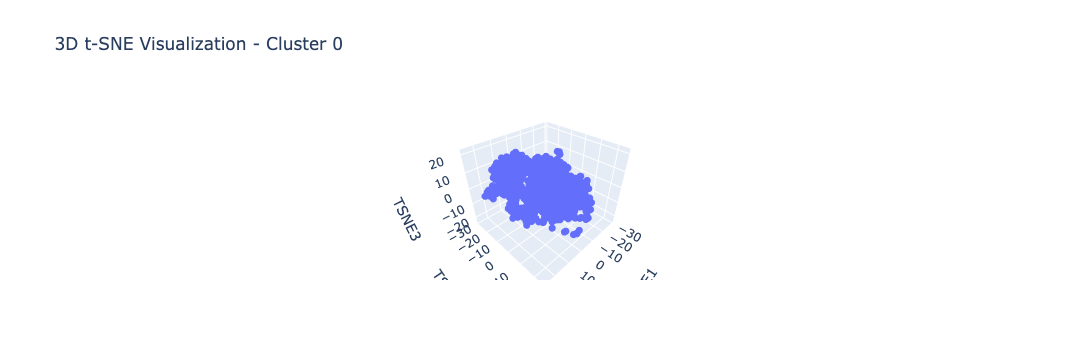

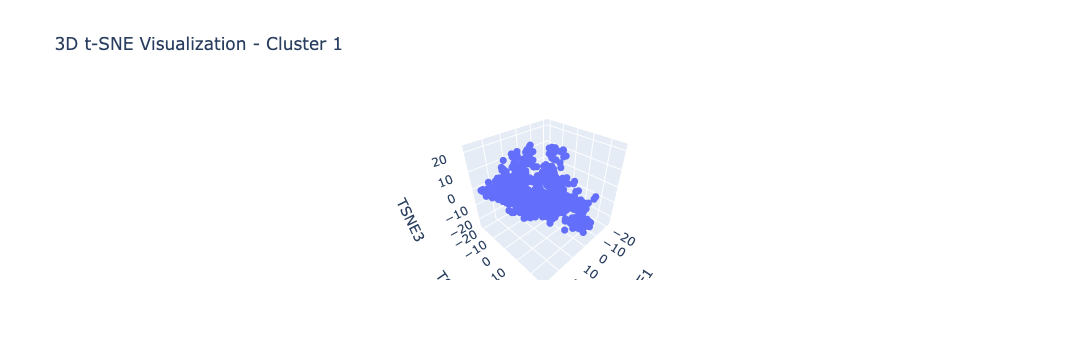

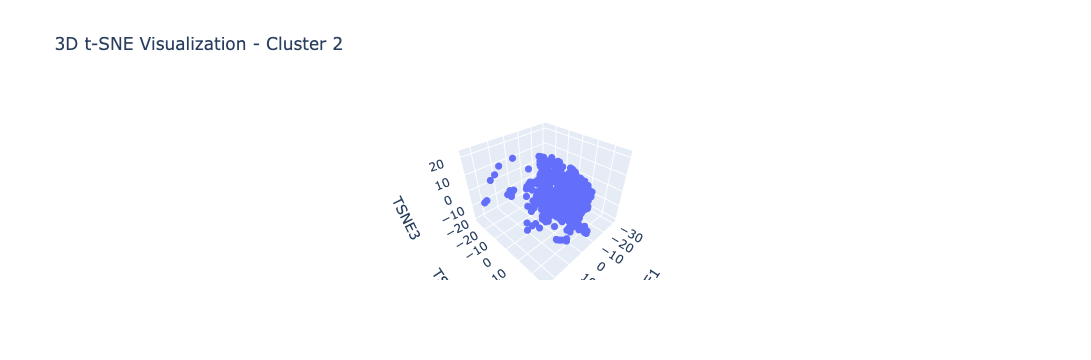

In [254]:
tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "TSNE3": X_tsne[:,2],
    "Cluster": KMeans3.labels_
})

# Plot each cluster separately
for cluster in [0, 1, 2]:

    cluster_df = tsne_df[tsne_df["Cluster"] == cluster]

    fig = px.scatter_3d(
        cluster_df,
        x="TSNE1",
        y="TSNE2",
        z="TSNE3",
        title=f"3D t-SNE Visualization - Cluster {cluster}"
    )

    fig.update_traces(
        marker=dict(size=4)
    )

    fig.show()

In [256]:
df_numeric_2["Cluster"] = KMeans3.labels_
df_numeric_2

,age,balance,duration,campaign,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_Q4,default_no,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster
83,1.741354,0.258004,0.832632,-0.613443,True,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,1
86,1.468629,-0.527801,1.818224,-0.613443,True,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,1
87,0.105003,-0.108910,1.637339,-0.613443,False,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,2
129,1.377720,0.303484,-0.241084,-0.613443,False,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,1
168,1.286812,-0.480270,-0.023094,-0.179720,True,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,False,False,False,False,True,False,...,False,True,False,True,False,True,False,False,False,0
39988,1.377720,0.271682,-0.213256,-0.179720,False,False,False,False,True,False,...,False,True,False,True,False,True,False,False,False,1
39990,-1.258623,-0.122246,-0.690978,-0.179720,False,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,0
39996,-0.894989,0.598930,-1.031877,0.254004,False,False,False,False,True,False,...,False,True,False,True,False,True,False,False,False,0


In [258]:
job_columns = ['job_admin',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown']

df_numeric_2['job'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['job'] = df_numeric_2['job'].str.replace('job_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2



,age,balance,duration,campaign,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,...,default_no,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job
83,1.741354,0.258004,0.832632,-0.613443,False,True,False,False,True,False,...,True,False,True,False,True,False,False,False,1,admin
86,1.468629,-0.527801,1.818224,-0.613443,False,True,False,False,True,False,...,True,False,True,False,True,False,False,False,1,admin
87,0.105003,-0.108910,1.637339,-0.613443,False,True,False,False,True,False,...,True,False,True,False,True,False,False,False,2,technician
129,1.377720,0.303484,-0.241084,-0.613443,False,True,False,False,True,False,...,True,False,True,False,True,False,False,False,1,services
168,1.286812,-0.480270,-0.023094,-0.179720,False,True,False,False,False,True,...,True,False,True,False,True,False,False,False,1,admin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,False,False,True,False,False,True,...,True,False,True,False,True,False,False,False,0,management
39988,1.377720,0.271682,-0.213256,-0.179720,True,False,False,False,False,True,...,True,False,True,False,True,False,False,False,1,management
39990,-1.258623,-0.122246,-0.690978,-0.179720,False,False,True,False,True,False,...,True,False,True,False,True,False,False,False,0,technician
39996,-0.894989,0.598930,-1.031877,0.254004,False,False,True,False,False,True,...,True,False,True,False,True,False,False,False,0,management


In [259]:
job_columns = ['marital_divorced', 'marital_married', 'marital_single']

df_numeric_2['marital'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['marital'] = df_numeric_2['marital'].str.replace('marital_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,education_primary,education_secondary,education_tertiary,education_unknown,housing_no,housing_yes,...,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job,marital
83,1.741354,0.258004,0.832632,-0.613443,False,True,False,False,False,True,...,False,True,False,True,False,False,False,1,admin,married
86,1.468629,-0.527801,1.818224,-0.613443,False,True,False,False,True,False,...,False,True,False,True,False,False,False,1,admin,married
87,0.105003,-0.108910,1.637339,-0.613443,False,True,False,False,False,True,...,False,True,False,True,False,False,False,2,technician,married
129,1.377720,0.303484,-0.241084,-0.613443,False,True,False,False,False,True,...,False,True,False,True,False,False,False,1,services,married
168,1.286812,-0.480270,-0.023094,-0.179720,False,False,True,False,True,False,...,False,True,False,True,False,False,False,1,admin,married
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,False,False,True,False,False,True,...,False,True,False,True,False,False,False,0,management,single
39988,1.377720,0.271682,-0.213256,-0.179720,False,False,True,False,True,False,...,False,True,False,True,False,False,False,1,management,divorced
39990,-1.258623,-0.122246,-0.690978,-0.179720,False,True,False,False,False,True,...,False,True,False,True,False,False,False,0,technician,single
39996,-0.894989,0.598930,-1.031877,0.254004,False,False,True,False,True,False,...,False,True,False,True,False,False,False,0,management,single


In [260]:
job_columns = ['education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown']

df_numeric_2['education'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['education'] = df_numeric_2['education'].str.replace('education_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,housing_no,housing_yes,contact_cellular,contact_telephone,contact_unknown,month_Q1,...,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job,marital,education
83,1.741354,0.258004,0.832632,-0.613443,False,True,False,False,True,False,...,True,False,True,False,False,False,1,admin,married,secondary
86,1.468629,-0.527801,1.818224,-0.613443,True,False,False,False,True,False,...,True,False,True,False,False,False,1,admin,married,secondary
87,0.105003,-0.108910,1.637339,-0.613443,False,True,False,False,True,False,...,True,False,True,False,False,False,2,technician,married,secondary
129,1.377720,0.303484,-0.241084,-0.613443,False,True,False,False,True,False,...,True,False,True,False,False,False,1,services,married,secondary
168,1.286812,-0.480270,-0.023094,-0.179720,True,False,False,False,True,False,...,True,False,True,False,False,False,1,admin,married,tertiary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,False,True,True,False,False,False,...,True,False,True,False,False,False,0,management,single,tertiary
39988,1.377720,0.271682,-0.213256,-0.179720,True,False,True,False,False,False,...,True,False,True,False,False,False,1,management,divorced,tertiary
39990,-1.258623,-0.122246,-0.690978,-0.179720,False,True,True,False,False,False,...,True,False,True,False,False,False,0,technician,single,secondary
39996,-0.894989,0.598930,-1.031877,0.254004,True,False,True,False,False,False,...,True,False,True,False,False,False,0,management,single,tertiary


In [261]:
job_columns = ['housing_no', 'housing_yes']

df_numeric_2['housing'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['housing'] = df_numeric_2['housing'].str.replace('housing_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,contact_cellular,contact_telephone,contact_unknown,month_Q1,month_Q2,month_Q3,...,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job,marital,education,housing
83,1.741354,0.258004,0.832632,-0.613443,False,False,True,False,True,False,...,False,True,False,False,False,1,admin,married,secondary,yes
86,1.468629,-0.527801,1.818224,-0.613443,False,False,True,False,True,False,...,False,True,False,False,False,1,admin,married,secondary,no
87,0.105003,-0.108910,1.637339,-0.613443,False,False,True,False,True,False,...,False,True,False,False,False,2,technician,married,secondary,yes
129,1.377720,0.303484,-0.241084,-0.613443,False,False,True,False,True,False,...,False,True,False,False,False,1,services,married,secondary,yes
168,1.286812,-0.480270,-0.023094,-0.179720,False,False,True,False,True,False,...,False,True,False,False,False,1,admin,married,tertiary,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,True,False,False,False,True,False,...,False,True,False,False,False,0,management,single,tertiary,yes
39988,1.377720,0.271682,-0.213256,-0.179720,True,False,False,False,True,False,...,False,True,False,False,False,1,management,divorced,tertiary,no
39990,-1.258623,-0.122246,-0.690978,-0.179720,True,False,False,False,True,False,...,False,True,False,False,False,0,technician,single,secondary,yes
39996,-0.894989,0.598930,-1.031877,0.254004,True,False,False,False,True,False,...,False,True,False,False,False,0,management,single,tertiary,no


In [262]:
job_columns = ['contact_cellular',
       'contact_telephone', 'contact_unknown']

df_numeric_2['contact'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['contact'] = df_numeric_2['contact'].str.replace('contact_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,month_Q1,month_Q2,month_Q3,month_Q4,default_no,default_yes,...,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job,marital,education,housing,contact
83,1.741354,0.258004,0.832632,-0.613443,False,True,False,False,True,False,...,True,False,False,False,1,admin,married,secondary,yes,unknown
86,1.468629,-0.527801,1.818224,-0.613443,False,True,False,False,True,False,...,True,False,False,False,1,admin,married,secondary,no,unknown
87,0.105003,-0.108910,1.637339,-0.613443,False,True,False,False,True,False,...,True,False,False,False,2,technician,married,secondary,yes,unknown
129,1.377720,0.303484,-0.241084,-0.613443,False,True,False,False,True,False,...,True,False,False,False,1,services,married,secondary,yes,unknown
168,1.286812,-0.480270,-0.023094,-0.179720,False,True,False,False,True,False,...,True,False,False,False,1,admin,married,tertiary,no,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,False,True,False,False,True,False,...,True,False,False,False,0,management,single,tertiary,yes,cellular
39988,1.377720,0.271682,-0.213256,-0.179720,False,True,False,False,True,False,...,True,False,False,False,1,management,divorced,tertiary,no,cellular
39990,-1.258623,-0.122246,-0.690978,-0.179720,False,True,False,False,True,False,...,True,False,False,False,0,technician,single,secondary,yes,cellular
39996,-0.894989,0.598930,-1.031877,0.254004,False,True,False,False,True,False,...,True,False,False,False,0,management,single,tertiary,no,cellular


In [263]:
job_columns = ['month_Q1', 'month_Q2',
       'month_Q3', 'month_Q4']

df_numeric_2['month'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['month'] = df_numeric_2['month'].str.replace('month_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,default_no,default_yes,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job,marital,education,housing,contact,month
83,1.741354,0.258004,0.832632,-0.613443,True,False,True,False,True,False,False,False,1,admin,married,secondary,yes,unknown,Q2
86,1.468629,-0.527801,1.818224,-0.613443,True,False,True,False,True,False,False,False,1,admin,married,secondary,no,unknown,Q2
87,0.105003,-0.108910,1.637339,-0.613443,True,False,True,False,True,False,False,False,2,technician,married,secondary,yes,unknown,Q2
129,1.377720,0.303484,-0.241084,-0.613443,True,False,True,False,True,False,False,False,1,services,married,secondary,yes,unknown,Q2
168,1.286812,-0.480270,-0.023094,-0.179720,True,False,True,False,True,False,False,False,1,admin,married,tertiary,no,unknown,Q2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,True,False,True,False,True,False,False,False,0,management,single,tertiary,yes,cellular,Q2
39988,1.377720,0.271682,-0.213256,-0.179720,True,False,True,False,True,False,False,False,1,management,divorced,tertiary,no,cellular,Q2
39990,-1.258623,-0.122246,-0.690978,-0.179720,True,False,True,False,True,False,False,False,0,technician,single,secondary,yes,cellular,Q2
39996,-0.894989,0.598930,-1.031877,0.254004,True,False,True,False,True,False,False,False,0,management,single,tertiary,no,cellular,Q2


In [264]:
job_columns = ['default_no', 'default_yes']

df_numeric_2['default'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['default'] = df_numeric_2['default'].str.replace('default_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,loan_no,loan_yes,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job,marital,education,housing,contact,month,default
83,1.741354,0.258004,0.832632,-0.613443,True,False,True,False,False,False,1,admin,married,secondary,yes,unknown,Q2,no
86,1.468629,-0.527801,1.818224,-0.613443,True,False,True,False,False,False,1,admin,married,secondary,no,unknown,Q2,no
87,0.105003,-0.108910,1.637339,-0.613443,True,False,True,False,False,False,2,technician,married,secondary,yes,unknown,Q2,no
129,1.377720,0.303484,-0.241084,-0.613443,True,False,True,False,False,False,1,services,married,secondary,yes,unknown,Q2,no
168,1.286812,-0.480270,-0.023094,-0.179720,True,False,True,False,False,False,1,admin,married,tertiary,no,unknown,Q2,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,True,False,True,False,False,False,0,management,single,tertiary,yes,cellular,Q2,no
39988,1.377720,0.271682,-0.213256,-0.179720,True,False,True,False,False,False,1,management,divorced,tertiary,no,cellular,Q2,no
39990,-1.258623,-0.122246,-0.690978,-0.179720,True,False,True,False,False,False,0,technician,single,secondary,yes,cellular,Q2,no
39996,-0.894989,0.598930,-1.031877,0.254004,True,False,True,False,False,False,0,management,single,tertiary,no,cellular,Q2,no


In [265]:
job_columns = ['loan_no', 'loan_yes']

df_numeric_2['loan'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['loan'] = df_numeric_2['loan'].str.replace('loan_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,day_first_week,day_second_week,day_third_week,day_fourth_week,Cluster,job,marital,education,housing,contact,month,default,loan
83,1.741354,0.258004,0.832632,-0.613443,True,False,False,False,1,admin,married,secondary,yes,unknown,Q2,no,no
86,1.468629,-0.527801,1.818224,-0.613443,True,False,False,False,1,admin,married,secondary,no,unknown,Q2,no,no
87,0.105003,-0.108910,1.637339,-0.613443,True,False,False,False,2,technician,married,secondary,yes,unknown,Q2,no,no
129,1.377720,0.303484,-0.241084,-0.613443,True,False,False,False,1,services,married,secondary,yes,unknown,Q2,no,no
168,1.286812,-0.480270,-0.023094,-0.179720,True,False,False,False,1,admin,married,tertiary,no,unknown,Q2,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,True,False,False,False,0,management,single,tertiary,yes,cellular,Q2,no,no
39988,1.377720,0.271682,-0.213256,-0.179720,True,False,False,False,1,management,divorced,tertiary,no,cellular,Q2,no,no
39990,-1.258623,-0.122246,-0.690978,-0.179720,True,False,False,False,0,technician,single,secondary,yes,cellular,Q2,no,no
39996,-0.894989,0.598930,-1.031877,0.254004,True,False,False,False,0,management,single,tertiary,no,cellular,Q2,no,no


In [266]:
job_columns = ['day_first_week', 'day_second_week',
       'day_third_week', 'day_fourth_week']

df_numeric_2['day'] = df_numeric_2[job_columns].idxmax(axis=1)

# Remove prefix
df_numeric_2['day'] = df_numeric_2['day'].str.replace('day_', '')

# Drop dummy columns
df_numeric_2 = df_numeric_2.drop(columns=job_columns)

df_numeric_2

,age,balance,duration,campaign,Cluster,job,marital,education,housing,contact,month,default,loan,day
83,1.741354,0.258004,0.832632,-0.613443,1,admin,married,secondary,yes,unknown,Q2,no,no,first_week
86,1.468629,-0.527801,1.818224,-0.613443,1,admin,married,secondary,no,unknown,Q2,no,no,first_week
87,0.105003,-0.108910,1.637339,-0.613443,2,technician,married,secondary,yes,unknown,Q2,no,no,first_week
129,1.377720,0.303484,-0.241084,-0.613443,1,services,married,secondary,yes,unknown,Q2,no,no,first_week
168,1.286812,-0.480270,-0.023094,-0.179720,1,admin,married,tertiary,no,unknown,Q2,no,no,first_week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,-0.985898,-0.325366,-0.795335,-0.613443,0,management,single,tertiary,yes,cellular,Q2,no,no,first_week
39988,1.377720,0.271682,-0.213256,-0.179720,1,management,divorced,tertiary,no,cellular,Q2,no,no,first_week
39990,-1.258623,-0.122246,-0.690978,-0.179720,0,technician,single,secondary,yes,cellular,Q2,no,no,first_week
39996,-0.894989,0.598930,-1.031877,0.254004,0,management,single,tertiary,no,cellular,Q2,no,no,first_week


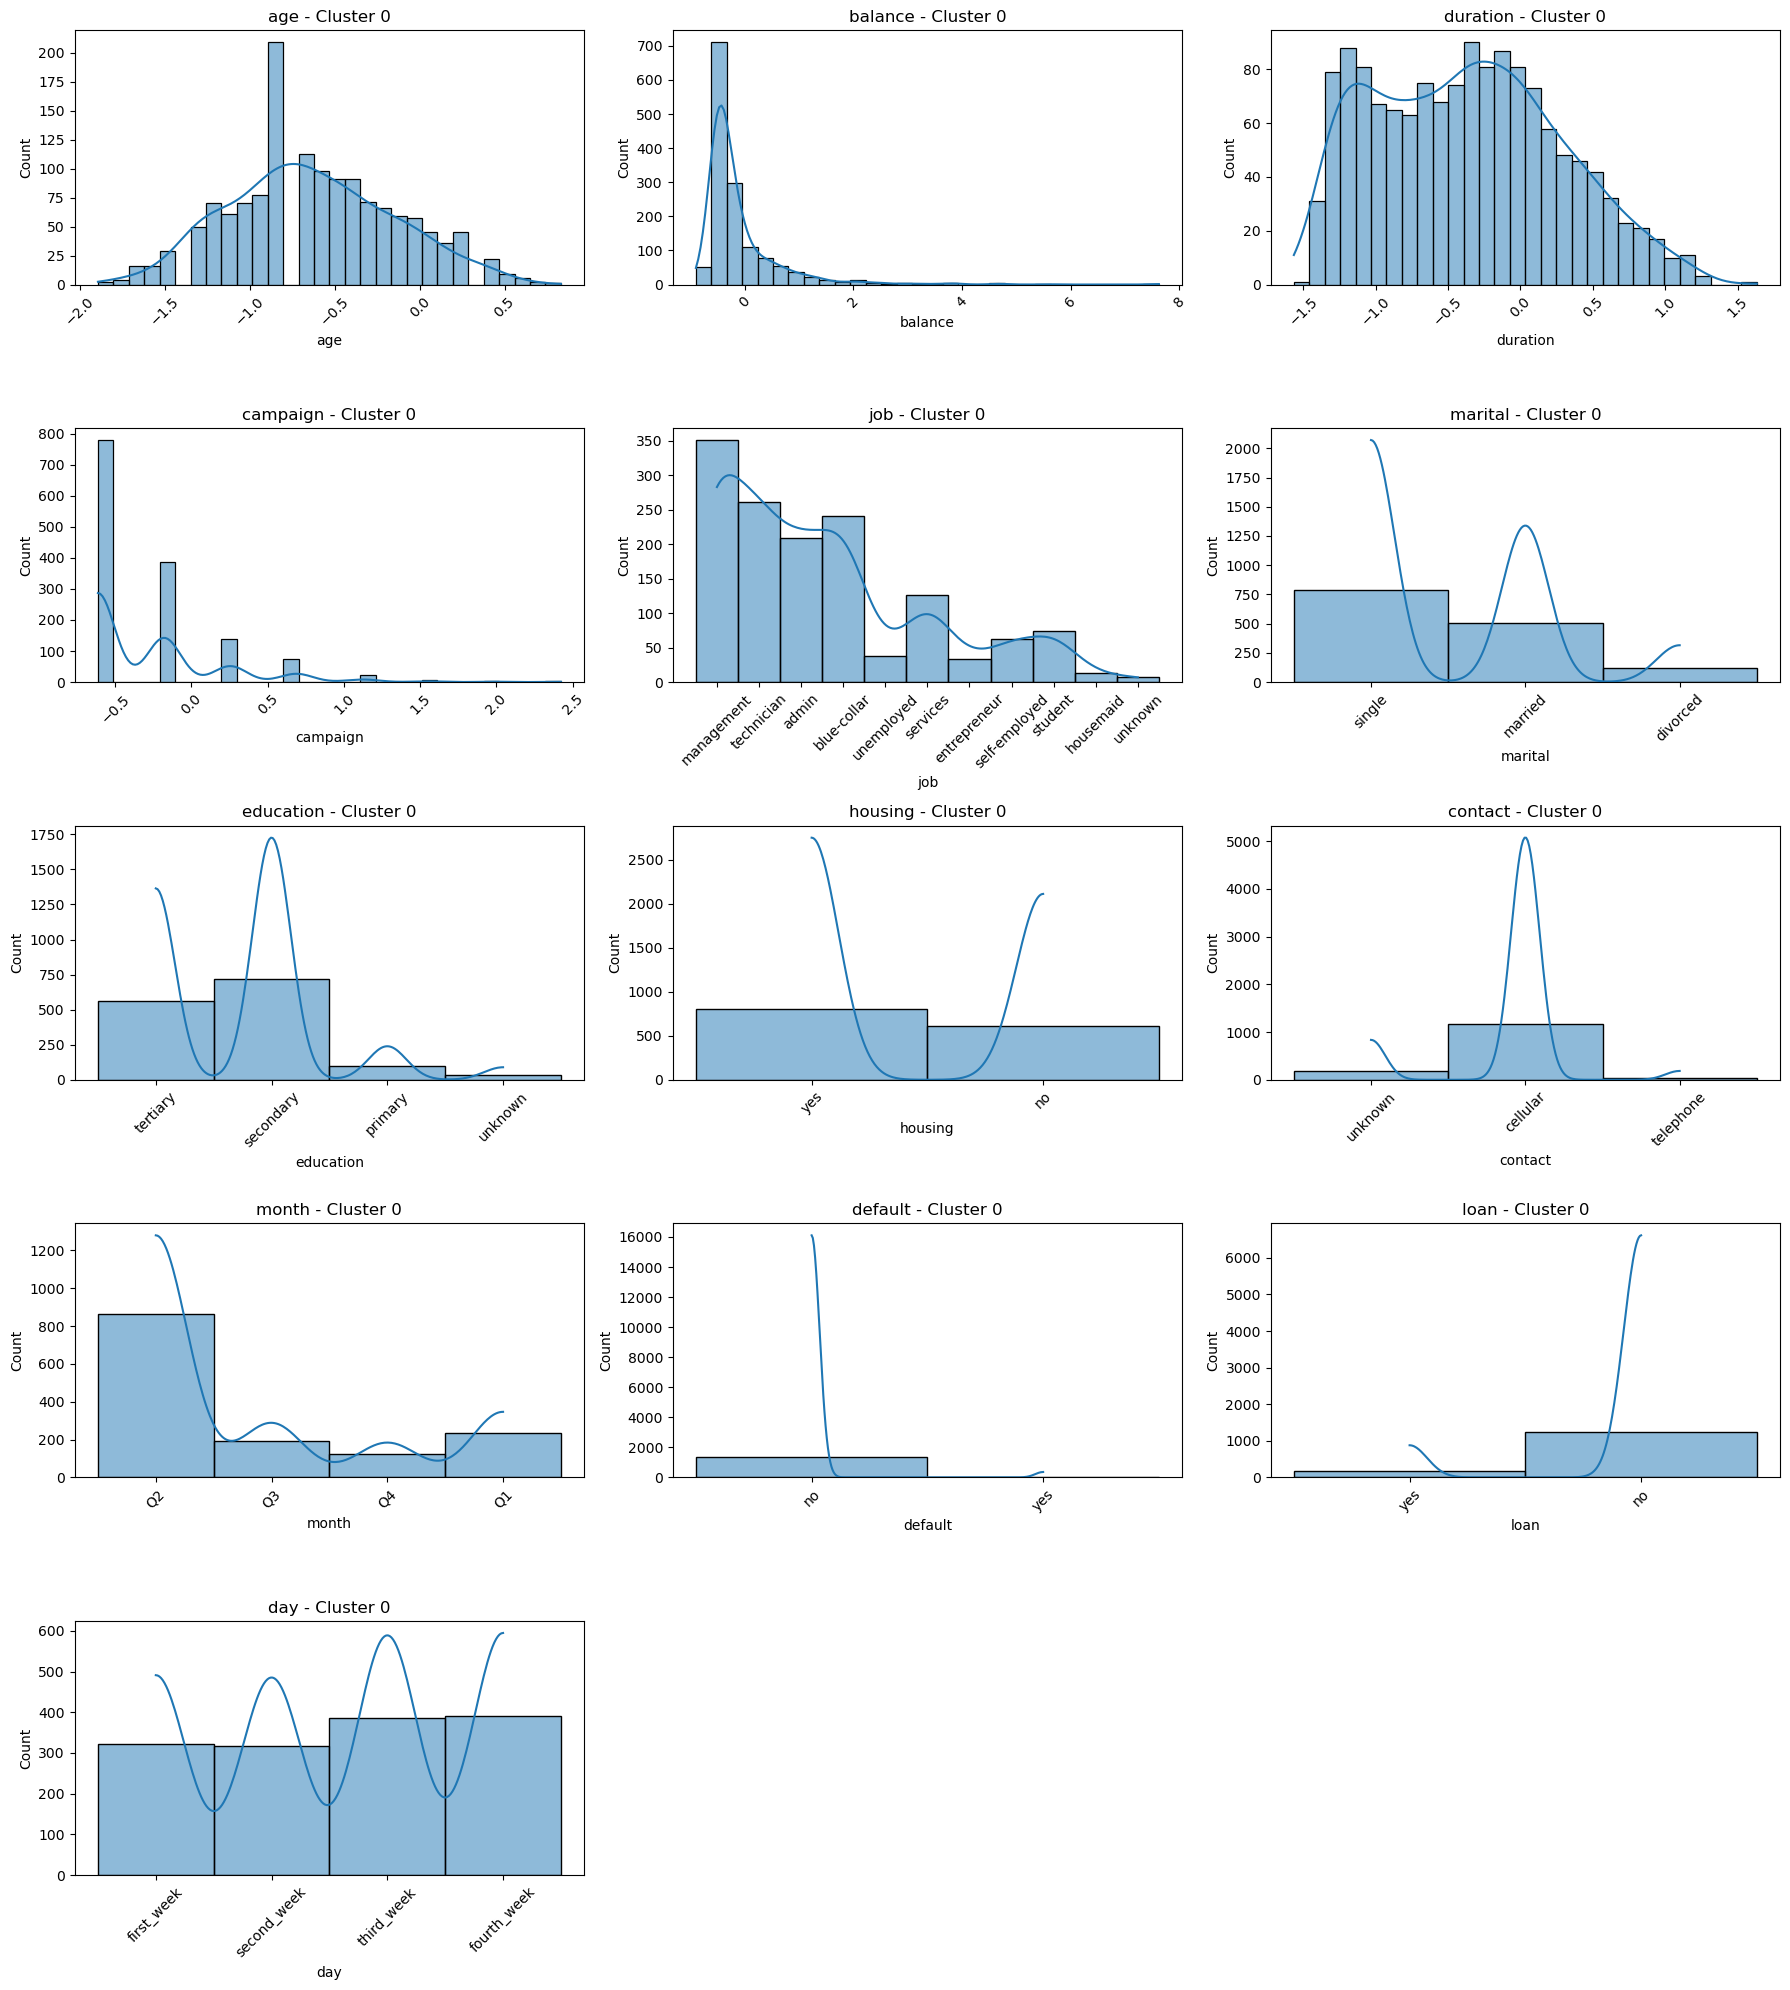

In [267]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

cluster = 0   # Change to 1 or 2

# Columns to plot
cols = df_numeric_2.columns.drop("Cluster")

# Grid settings
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4*n_rows)
)

# Flatten axes for easy looping
axes = axes.flatten()

# Filter cluster data once
cluster_data = df_numeric_2[df_numeric_2["Cluster"] == cluster]

for i, col in enumerate(cols):

    sns.histplot(
        data=cluster_data,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} - Cluster {cluster}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Cluster 0
Age: Distribution is centered below 0, with most values between approximately -1.2 and -0.2. Customers in Cluster 0 tend to be younger than the overall average. There are relatively few older customers.
Balance: Strong right-skewed distribution. Most observations are clustered near or below the mean, with a few very large positive values.	Most customers have below-average or average account balances, while a small number of customers have very high balances (outliers).
Duration: Distribution peaks slightly below 0, although it spans both negative and positive values.	Call durations are generally slightly shorter than the dataset average, with some longer calls present.
Campaign: Most observations are at 0 or very low values with a long right tail.	Below-average campaign contacts are typical for this cluster. Very high campaign counts are uncommon.
Job	Management, technician, admin, and blue-collar are the largest groups. These occupations are more common in Cluster 0, while retired, student, housemaid, and unemployed are less common.
Marital	Single and married dominate; divorced is relatively rare. The cluster is primarily composed of single and married customers.
Education	Secondary education is the largest category, followed by tertiary. Secondary education is above average within this cluster, while primary and unknown education occur less frequently.
Housing Loan: Both yes and no are represented, with "Yes" appearing slightly more frequent.	Housing loans are fairly common in this cluster.
Contact:Cellular contact overwhelmingly dominates. Customers are primarily contacted by cellular phone; telephone and unknown contacts are much less common.
Month: Q2 has the highest frequency, followed by Q1.Most contacts occurred during Q2, while Q3 and Q4 are less represented. Default	Almost every customer has No default, with very few Yes. Cluster 0 has a very low credit default rate, indicating generally good credit history.
Personal Loan	The majority of customers have No personal loan. Most customers do not have personal loans.
Day (Week)	Contacts are distributed across all four weeks, with a slight increase during the third and fourth weeks. There is no strong weekly contact pattern, although contacts appear somewhat more frequent toward the end of the month.

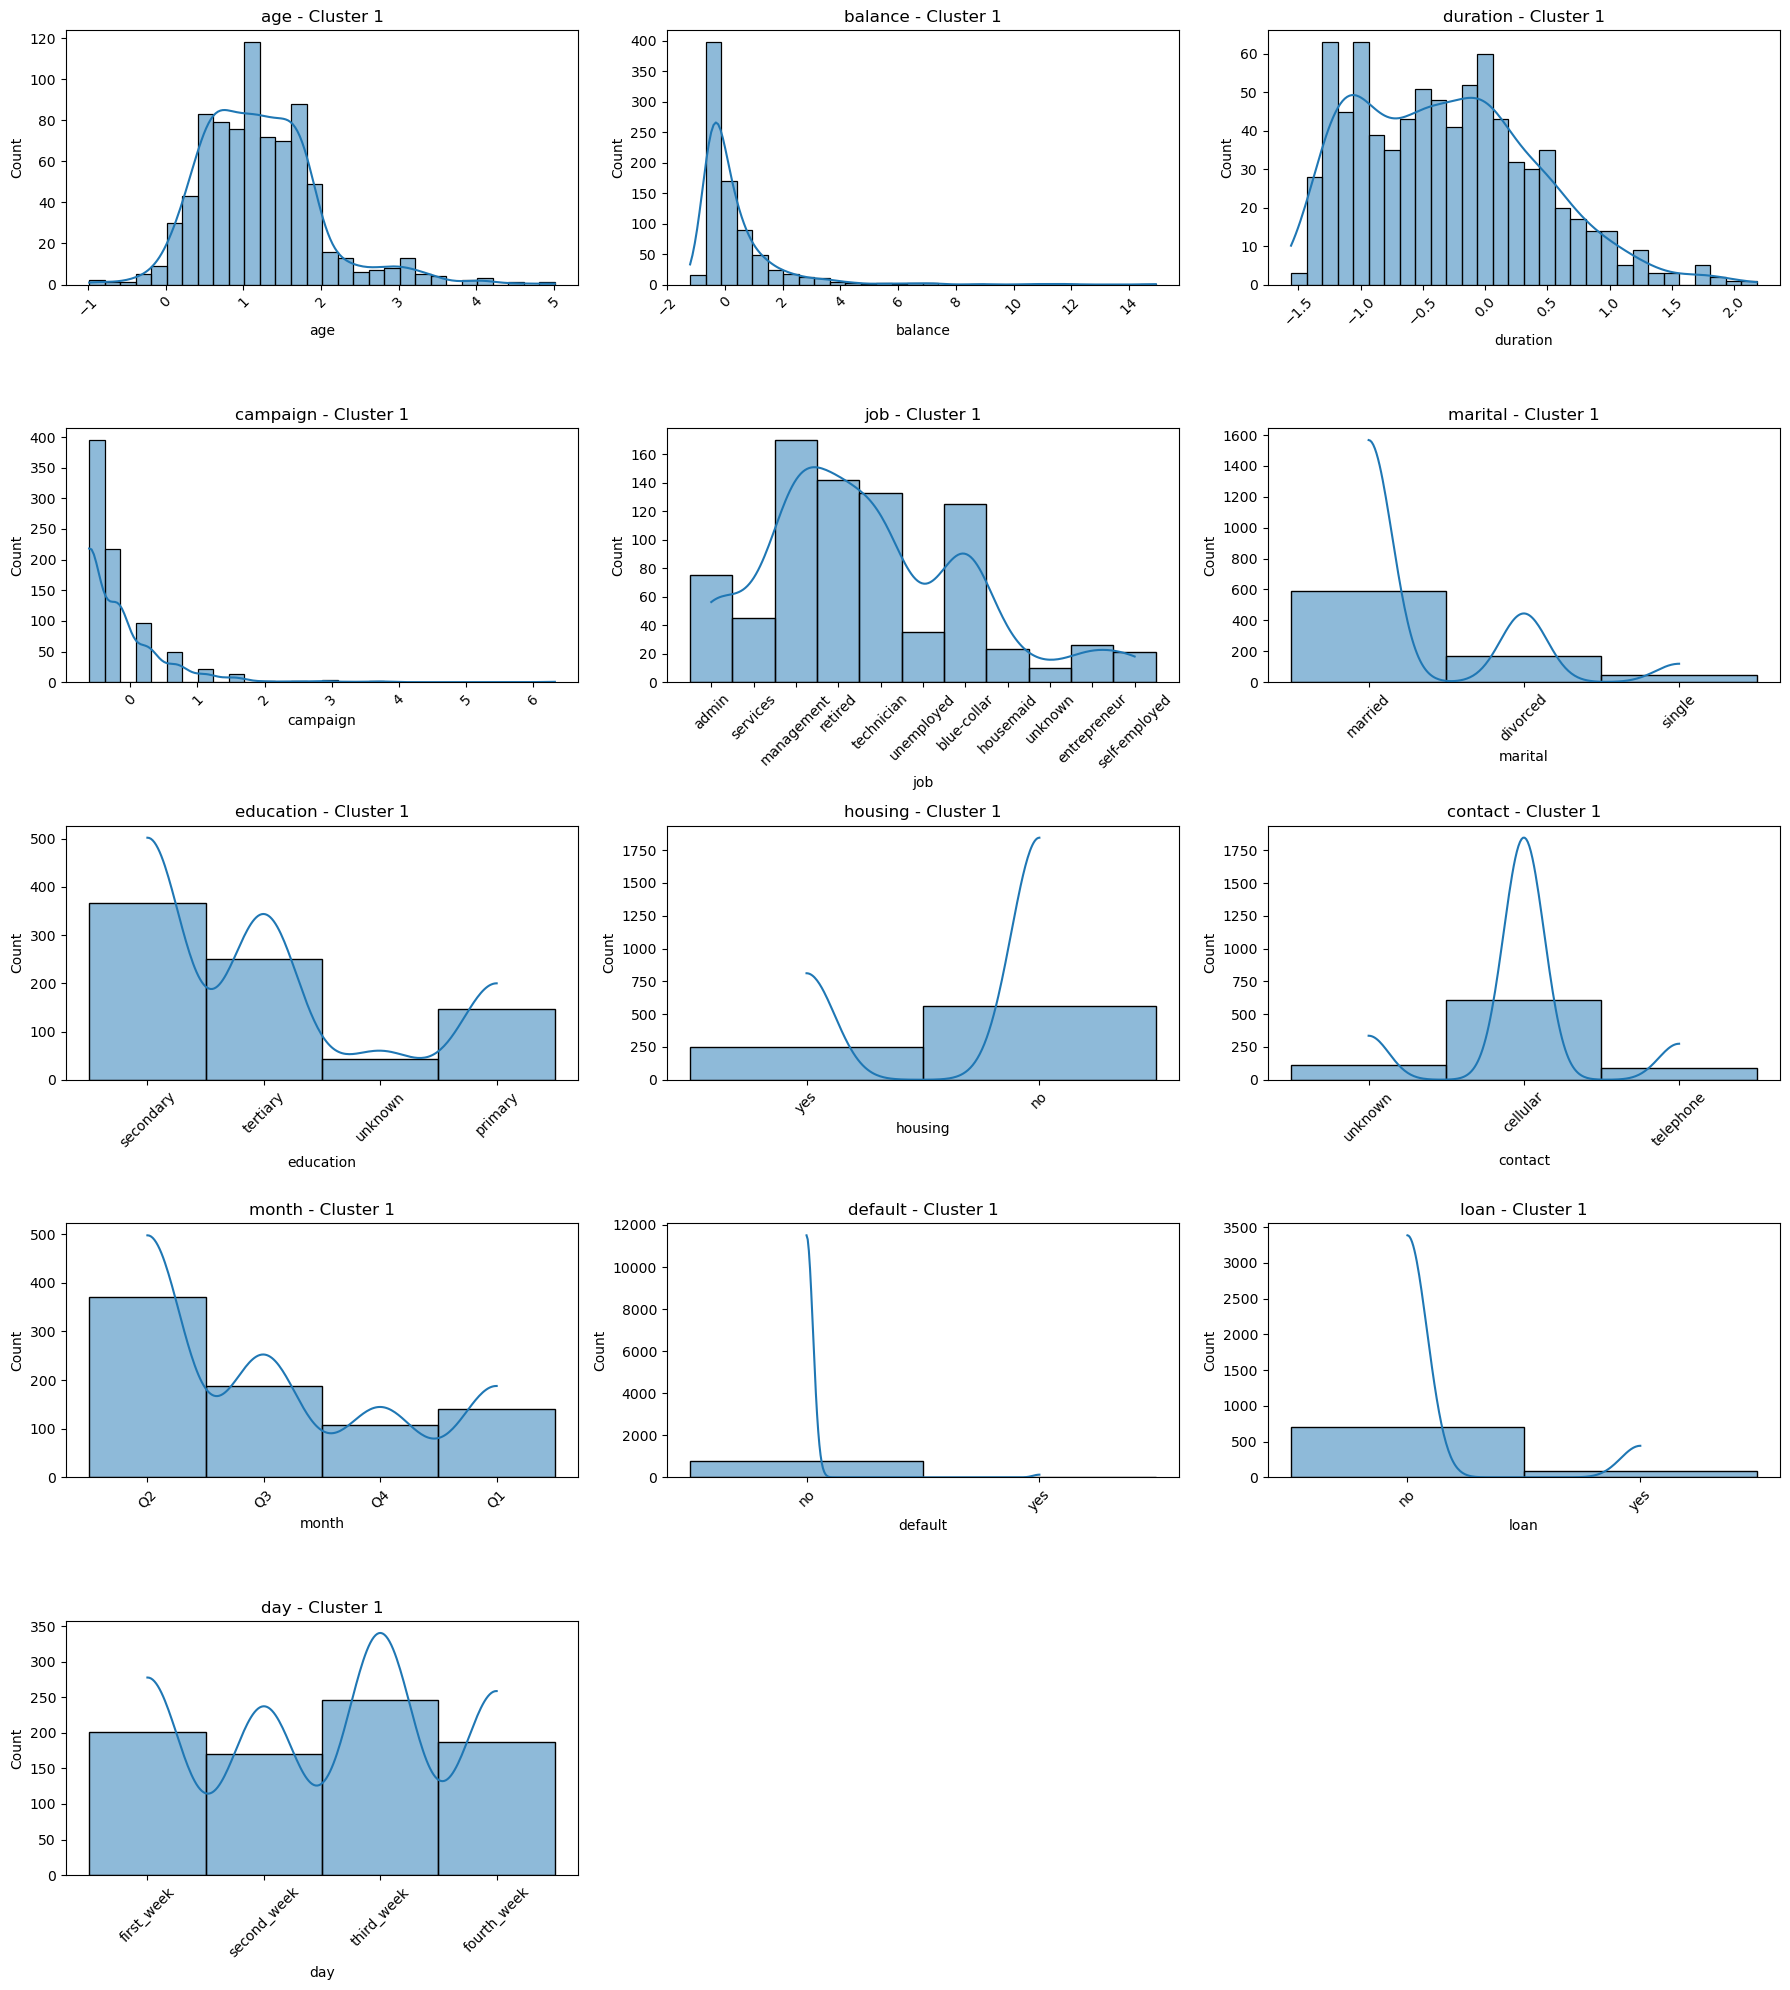

In [268]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

cluster = 1   # Change to 1 or 2

# Columns to plot
cols = df_numeric_2.columns.drop("Cluster")

# Grid settings
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4*n_rows)
)

# Flatten axes for easy looping
axes = axes.flatten()

# Filter cluster data once
cluster_data = df_numeric_2[df_numeric_2["Cluster"] == cluster]

for i, col in enumerate(cols):

    sns.histplot(
        data=cluster_data,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} - Cluster {cluster}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Cluster 1
Age	Distribution is centered above 0, with most values between about 0.5 and 1.5.	Customers are older than the overall average.
Balance	Strongly right-skewed. Most customers have balances near the mean with a few very large outliers.	Most customers have average to slightly below-average balances, while a few have exceptionally high balances.
Duration	Distribution is centered slightly below 0 with a long right tail.	Call durations are around average to slightly below average, although some customers had much longer calls.
Campaign	Most values are close to 0 with a long right tail.	Customers were contacted relatively few times, with only a few receiving many campaign contacts.
Job	Retired is the largest category, followed by management and technician.	This cluster contains a high proportion of retired customers, with management and technician also well represented.
Marital	Married customers dominate; divorced and single are much less common.	The cluster is composed primarily of married customers.
Education	Secondary education is the largest group, followed by tertiary.	Secondary education predominates, while primary and unknown education are less frequent.
Housing Loan	"No" is much more common than "Yes".	Most customers do not have a housing loan.
Contact	Cellular is overwhelmingly the primary contact method.	Customers are primarily contacted via cellular phone.
Month	Q2 has the highest frequency.	Most marketing contacts occurred during Q2.
Default	Almost all customers have No default.	Very few customers have a history of credit default.
Loan	Most customers have No personal loan.	Personal loans are uncommon in this cluster.
Day	Contacts are spread fairly evenly across the month, with a slight concentration in the middle.	There is no strong day-of-month pattern for contacts.

import seaborn as sns
import matplotlib.pyplot as plt
import math

cluster = 2   # Change to 1 or 2

# Columns to plot
cols = df_numeric_2.columns.drop("Cluster")

# Grid settings
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4*n_rows)
)

# Flatten axes for easy looping
axes = axes.flatten()

# Filter cluster data once
cluster_data = df_numeric_2[df_numeric_2["Cluster"] == cluster]

for i, col in enumerate(cols):

    sns.histplot(
        data=cluster_data,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} - Cluster {cluster}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Cluster 2
Age	Distribution is centered around 0 with values spread on both sides.	Customers are close to the overall average age, with a wider age range than the other clusters.
Balance	Strongly right-skewed with most balances near the mean and a few large outliers.	Most customers have average balances, while a small number have very high account balances.
Duration	Distribution is concentrated around the center with fewer long calls.	Call durations are around the dataset average, with relatively few extremely long calls.
Campaign	Most customers were contacted only a few times; distribution has a long right tail.	Customers generally received few campaign contacts, with only a small number contacted many times.
Job	Technician is the largest occupation, followed by blue-collar and management.	The cluster is dominated by technicians, with substantial representation from blue-collar and management occupations.
Marital	Married customers are the largest group, followed by single customers; divorced is least common.	The cluster consists primarily of married customers.
Education	Secondary education is the largest category, followed by tertiary.	Most customers have secondary education, while tertiary education is also common.
Housing Loan	"Yes" appears slightly more common than "No".	A relatively large proportion of customers have housing loans.
Contact	Cellular is overwhelmingly the dominant contact method.	Customers are contacted primarily via cellular phone.
Month	Most contacts occurred during Q2, with fewer in Q3 and Q4.	Marketing activity is concentrated in Q2.
Default	Almost all customers have No default.	The cluster has a very low credit default rate.
Loan	Customers without personal loans are more common than those with loans.	Most customers do not have personal loans.
Day	Contacts are spread across the month with a slight concentration in the middle.

In [86]:
rows = []

for model_name, metrics in results.items():
    row = {'model_name': model_name}

    for k, v in metrics.items():
        if k not in ['model', 'params']:
            row[k] = v

    rows.append(row)

comparison_df = pd.DataFrame(rows)

print(comparison_df)

                    model_name  accuracy       mae       mse      rmse  \
0           LogisticRegression  0.855625  0.144375  0.144375  0.379967   
1       RandomForestClassifier  0.857375  0.142625  0.142625  0.377657   
2             GradientBoosting  0.933750  0.066250  0.066250  0.257391   
3            XGBoostClassifier  0.865375  0.134625  0.134625  0.366913   
4               LGBMClassifier  0.694250  0.305750  0.305750  0.552947   
5                SGDClassifier  0.842875  0.157125  0.157125  0.396390   
6                  BernoulliNB  0.917875  0.082125  0.082125  0.286575   
7                   GaussianNB  0.881375  0.118625  0.118625  0.344420   
8              NearestCentroid  0.887875  0.112125  0.112125  0.334851   
9                   Perceptron  0.767625  0.232375  0.232375  0.482053   
10  LinearDiscriminantAnalysis  0.930000  0.070000  0.070000  0.264575   
11             RidgeClassifier  0.868625  0.131375  0.131375  0.362457   
12           RidgeClassifierCV  0.8686